# 单资产端到端 Demo

这个 notebook 在 `demo/single_asset_demo` 下完整演示三段链路：

1. 用 `factor_engine` 基于共享行情生成常用技术因子，并写入本目录下的 factor lake。
2. 用 `single_asset_alpha` 走两条 alpha 路径：
   - 多因子路径：`factor_lake -> FactorThresholdSignal -> target_position`
   - Python 文件路径：`python_strategy_path.py -> target_position`
3. 用 `single_asset_backtest` 对两条路径分别回测，并把结果都保存到本目录下。

建议使用能导入 `backtrader` 的 Python 内核，例如 `QSPG2025I001`。

In [1]:
from __future__ import annotations

from pathlib import Path
import json
import shutil
import sys

import pandas as pd

try:
    from IPython.display import display
except ImportError:
    display = print

DEMO_ROOT = Path('/home/yluel/share/projects/quantsociety_backend_project/demo/single_asset_demo')
REPO_ROOT = DEMO_ROOT.parents[1]
AGGREGATE_BARS_ROOT = Path('/home/yluel/share/projects/massive_parquet/cleaned_massive_data/aggregate_bars')
SYMBOL = 'A'
START_DATE = '2020-01-01'
END_DATE = '2025-12-31'

for candidate in (
    REPO_ROOT,
    REPO_ROOT / 'backtest_layer',
    REPO_ROOT / 'factor_layer' / 'factor_engine',
    DEMO_ROOT,
):
    text = str(candidate)
    if text not in sys.path:
        sys.path.insert(0, text)

from strategy_layer.data import FactorRef, build_factor_panel, load_single_asset_ohlcv, project_single_asset
from strategy_layer.single_asset_alpha.config_runner import run_from_config
from single_asset_backtest.config import BacktestConfig
from single_asset_backtest.runner import run_single_asset_backtest
import backtrader  # noqa: F401

for path in (
    DEMO_ROOT / 'factor_lake',
    DEMO_ROOT / 'cache',
    DEMO_ROOT / 'outputs',
):
    path.mkdir(parents=True, exist_ok=True)

print(f'Python executable: {sys.executable}')
print(f'Demo root: {DEMO_ROOT}')
print(f'Using symbol={SYMBOL}, start={START_DATE}, end={END_DATE}')

Python executable: /home/yluel/anaconda3/envs/QSPG2025I001/bin/python
Demo root: /home/yluel/share/projects/quantsociety_backend_project/demo/single_asset_demo
Using symbol=A, start=2020-01-01, end=2025-12-31


In [12]:
from api.columns import col

from api.factor import Factor

from api.operators import protected_div, ts_mom, ts_rsi, ts_sma, ts_std_dev

from backend.pandas_backend import PandasBackend

from runtime.engine import FactorEngine

from storage.datasource import DataSource



class InMemorySeriesSource(DataSource):

    def __init__(self, data: dict[str, pd.Series]) -> None:

        self.data = data



    def load_column(self, name: str):

        return self.data[name]



def build_market_source(market_data: pd.DataFrame, symbol: str) -> dict[str, pd.Series]:

    panel_index = pd.MultiIndex.from_arrays(

        [market_data.index, [symbol] * len(market_data)],

        names=['timestamp', 'instrument'],

    )

    return {

        column: pd.Series(market_data[column].astype(float).to_numpy(), index=panel_index)

        for column in ['open', 'high', 'low', 'close', 'volume']

    }



def write_factor_series_to_lake(lake_root: Path, factor_id: str, series: pd.Series) -> pd.DataFrame:

    frame = series.rename('value').reset_index()

    frame.columns = ['datetime', 'asset', 'value']

    frame = frame.dropna(subset=['datetime', 'asset', 'value']).copy()



    factor_root = lake_root / 'factors' / factor_id

    if factor_root.exists():

        shutil.rmtree(factor_root)



    for year, partition in frame.groupby(frame['datetime'].dt.year):

        target = factor_root / f'year={int(year)}'

        target.mkdir(parents=True, exist_ok=True)

        partition.to_parquet(target / 'data.parquet', index=False)



    return frame



def scalarize(value):

    if isinstance(value, pd.Timestamp):

        return str(value)

    if isinstance(value, Path):

        return str(value)

    if hasattr(value, 'item'):

        try:

            return value.item()

        except Exception:

            pass

    if isinstance(value, (str, int, float, bool)) or value is None:

        return value

    return str(value)



def persist_backtest_report(name: str, report: dict) -> Path:

    report_root = DEMO_ROOT / 'outputs' / 'backtests' / name

    report_root.mkdir(parents=True, exist_ok=True)



    summary = {key: scalarize(value) for key, value in report['summary'].items()}

    metrics = {key: scalarize(value) for key, value in report['metrics'].items()}



    (report_root / 'summary.json').write_text(json.dumps(summary, ensure_ascii=False, indent=2))

    (report_root / 'metrics.json').write_text(json.dumps(metrics, ensure_ascii=False, indent=2))



    report['returns']['equity_curve'].rename('equity_curve').to_csv(

        report_root / 'equity_curve.csv', index_label='timestamp'

    )

    report['returns']['period_return'].rename('period_return').to_csv(

        report_root / 'period_return.csv', index_label='timestamp'

    )

    report['returns']['realized_position'].rename('realized_position').to_csv(

        report_root / 'realized_position.csv', index_label='timestamp'

    )

    return report_root



FACTOR_SPECS = [

    {

        'factor_id': 'demo_mom_2_v1',

        'alias': 'mom_2',

        'factor': Factor(

            name='demo_mom_2_v1',

            expr=ts_mom(col('close'), 2),

            freq='1d',

            description='2-bar price momentum',

        ),

    },

    {

        'factor_id': 'demo_sma_gap_4_v1',

        'alias': 'sma_gap_4',

        'factor': Factor(

            name='demo_sma_gap_4_v1',

            expr=protected_div(col('close'), ts_sma(col('close'), 4), default=1.0),

            freq='1d',

            description='close / sma4',

        ),

    },

    {

        'factor_id': 'demo_rsi_6_v1',

        'alias': 'rsi_6',

        'factor': Factor(

            name='demo_rsi_6_v1',

            expr=ts_rsi(col('close'), 6),

            freq='1d',

            description='6-bar RSI',

        ),

    },

    {

        'factor_id': 'demo_vol_5_v1',

        'alias': 'vol_5',

        'factor': Factor(

            name='demo_vol_5_v1',

            expr=ts_std_dev(col('close'), 5),

            freq='1d',

            description='5-bar close volatility',

        ),

    },

]

In [3]:
market_data = load_single_asset_ohlcv(
    symbol=SYMBOL,
    mode='aggregate_bars_daily_summary',
    aggregate_bars_root=AGGREGATE_BARS_ROOT,
    aggregate_dataset='daily_market_summary',
    freq='1d',
    start_date=START_DATE,
    end_date=END_DATE,
    cache_root=DEMO_ROOT / 'cache' / 'market_data',
)

market_profile = pd.DataFrame(
    {
        'value': [
            SYMBOL,
            len(market_data),
            str(market_data.index.min()),
            str(market_data.index.max()),
            ', '.join(market_data.columns),
        ]
    },
    index=['symbol', 'rows', 'start', 'end', 'columns'],
)

display(market_profile)
display(market_data.head())
display(market_data.tail())

,value
symbol,A
rows,1508
start,2020-01-02 00:00:00
end,2025-12-31 00:00:00
columns,"open, high, low, close, volume"


,open,high,low,close,volume
timestamp,,,,,
2020-01-02,85.90,86.35,85.20,85.95,1417716.0
2020-01-03,84.67,85.33,84.50,84.57,1135486.0
2020-01-06,84.00,84.82,83.60,84.82,2007096.0
2020-01-07,83.96,85.26,83.94,85.08,1742123.0
2020-01-08,85.96,86.47,85.20,85.92,1877992.0


,open,high,low,close,volume
timestamp,,,,,
2025-12-24,138.35,138.57,137.7700,138.32,508961.0
2025-12-26,138.50,138.63,137.8700,138.39,739337.0
2025-12-29,138.40,139.07,137.6200,137.93,1640851.0
2025-12-30,137.57,138.16,136.8301,137.62,2423111.0
2025-12-31,137.61,137.97,136.0400,136.07,949976.0


In [13]:
factor_lake_root = DEMO_ROOT / 'factor_lake'

if factor_lake_root.exists():

    shutil.rmtree(factor_lake_root)

factor_lake_root.mkdir(parents=True, exist_ok=True)



engine = FactorEngine(

    backend=PandasBackend(),

    data_source=InMemorySeriesSource(build_market_source(market_data, SYMBOL)),

)



factor_rows = []

for spec in FACTOR_SPECS:

    series = engine.run(spec['factor'])['result']

    written = write_factor_series_to_lake(factor_lake_root, spec['factor_id'], series)

    factor_rows.append(

        {

            'factor_id': spec['factor_id'],

            'alias': spec['alias'],

            'rows_written': int(len(written)),

            'start': str(written['datetime'].min()) if not written.empty else None,

            'end': str(written['datetime'].max()) if not written.empty else None,

        }

    )



factor_inventory = pd.DataFrame(factor_rows)

factor_panel = build_factor_panel(

    factor_lake_root,

    [FactorRef(spec['factor_id'], spec['alias']) for spec in FACTOR_SPECS],

    start=START_DATE,

    end=END_DATE,

    symbols=[SYMBOL],

    align_method='outer',

)

single_asset_factors = project_single_asset(factor_panel, SYMBOL)



display(factor_inventory)

display(single_asset_factors.tail(10))

2026-04-04 21:55:01 | INFO    | factor_engine.runtime.engine | 开始执行因子 'demo_mom_2_v1'
2026-04-04 21:55:01 | INFO    | factor_engine.runtime.engine | 开始编译因子 'demo_mom_2_v1'
2026-04-04 21:55:01 | INFO    | factor_engine.runtime.engine | 完成编译因子 'demo_mom_2_v1'，lookback=2，耗时 0.00s
2026-04-04 21:55:01 | INFO    | factor_engine.runtime.engine | 完成执行因子 'demo_mom_2_v1'，结果行数=1508，非空=1506，耗时 0.01s
2026-04-04 21:55:01 | INFO    | factor_engine.runtime.engine | 开始执行因子 'demo_sma_gap_4_v1'
2026-04-04 21:55:01 | INFO    | factor_engine.runtime.engine | 开始编译因子 'demo_sma_gap_4_v1'
2026-04-04 21:55:01 | INFO    | factor_engine.runtime.engine | 完成编译因子 'demo_sma_gap_4_v1'，lookback=4，耗时 0.00s
2026-04-04 21:55:01 | INFO    | factor_engine.runtime.engine | 完成执行因子 'demo_sma_gap_4_v1'，结果行数=1508，非空=1508，耗时 0.01s
2026-04-04 21:55:01 | INFO    | factor_engine.runtime.engine | 开始执行因子 'demo_rsi_6_v1'
2026-04-04 21:55:01 | INFO    | factor_engine.runtime.engine | 开始编译因子 'demo_rsi_6_v1'
2026-04-04 21:55:01 | INFO    

,factor_id,alias,rows_written,start,end
0,demo_mom_2_v1,mom_2,1506,2020-01-06 00:00:00,2025-12-31 00:00:00
1,demo_sma_gap_4_v1,sma_gap_4,1508,2020-01-02 00:00:00,2025-12-31 00:00:00
2,demo_rsi_6_v1,rsi_6,1507,2020-01-03 00:00:00,2025-12-31 00:00:00
3,demo_vol_5_v1,vol_5,1504,2020-01-08 00:00:00,2025-12-31 00:00:00


,mom_2,sma_gap_4,rsi_6,vol_5
timestamp,,,,
2025-12-17,-3.94,0.982936,22.253239,2.253386
2025-12-18,-2.29,0.989609,24.109356,1.744127
2025-12-19,0.58,0.998127,27.069294,1.709509
2025-12-22,1.62,1.008665,37.994652,1.098372
2025-12-23,1.12,1.004392,37.159649,0.852455
2025-12-24,-0.20,1.001521,36.916260,0.742105
2025-12-26,0.03,0.999946,37.772186,0.523049
2025-12-29,-0.39,0.997685,34.121391,0.222104
2025-12-30,-0.77,0.996777,31.647718,0.337831


In [21]:
multi_factor_config_path = DEMO_ROOT / 'configs' / 'multi_factor_factor_lake.yaml'
multi_factor_result = run_from_config(multi_factor_config_path)
multi_factor_target_position = multi_factor_result['target_position']

print(f'Multi-factor config: {multi_factor_config_path}')
print(f'Config snapshot: {multi_factor_result["config_snapshot"]}')
display(multi_factor_target_position.head(10))
display(multi_factor_target_position.tail(10))

2026-04-04 22:04:19 | INFO    | single_asset_alpha.pipeline | ═══ 策略流水线启动 [A] ═══
2026-04-04 22:04:19 | INFO    | single_asset_alpha.pipeline | 信号生成器: FactorThresholdSignal(name='FactorThreshold', params={'factor_names': ['mom_2', 'sma_gap_4', 'rsi_6', 'vol_5'], 'factor_weights': {'mom_2': 0.35, 'sma_gap_4': 0.3, 'rsi_6': 0.25, 'vol_5': -0.1}, 'normalize': True, 'zscore_window': 30})
2026-04-04 22:04:19 | INFO    | single_asset_alpha.pipeline | 仓位映射器: ThresholdPositionMapper(name='ThresholdMapper', params={'long_entry_threshold': 0.16, 'long_exit_threshold': -0.02, 'short_entry_threshold': -0.16, 'short_exit_threshold': 0.02, 'allow_short': False, 'position_size': 1.0, 'shift_bars': 1})
2026-04-04 22:04:19 | INFO    | single_asset_alpha.pipeline | Step 1/5: 使用外部提供的行情数据
2026-04-04 22:04:19 | INFO    | single_asset_alpha.pipeline |   行情数据: 1508 行, 时间范围: [2020-01-02 00:00:00 ~ 2025-12-31 00:00:00]
2026-04-04 22:04:19 | INFO    | single_asset_alpha.pipeline | Step 2/5: 生成择时信号 (C-1)...
2026

Multi-factor config: /home/yluel/share/projects/quantsociety_backend_project/demo/single_asset_demo/configs/multi_factor_factor_lake.yaml
Config snapshot: /home/yluel/share/projects/quantsociety_backend_project/demo/single_asset_demo/outputs/multi_factor_alpha/config_snapshot.yaml


,timestamp,symbol,target_position,signal_value,action_name
0,2020-01-02,A,0.0,0.0,HOLD
1,2020-01-03,A,0.0,0.0,HOLD
2,2020-01-06,A,0.0,0.0,HOLD
3,2020-01-07,A,0.0,0.0,HOLD
4,2020-01-08,A,0.0,0.0,HOLD
5,2020-01-09,A,0.0,0.0,HOLD
6,2020-01-10,A,0.0,0.0,HOLD
7,2020-01-13,A,0.0,0.0,HOLD
8,2020-01-14,A,0.0,0.0,HOLD
9,2020-01-15,A,0.0,0.0,HOLD


,timestamp,symbol,target_position,signal_value,action_name
1498,2025-12-17,A,0.0,-0.396835,HOLD
1499,2025-12-18,A,0.0,-0.729868,HOLD
1500,2025-12-19,A,0.0,-0.491750,HOLD
1501,2025-12-22,A,0.0,-0.043329,ENTRY_LONG
1502,2025-12-23,A,1.0,0.416631,HOLD
1503,2025-12-24,A,1.0,0.318906,HOLD
1504,2025-12-26,A,1.0,0.186125,HOLD
1505,2025-12-29,A,1.0,0.246356,HOLD
1506,2025-12-30,A,1.0,0.116704,HOLD
1507,2025-12-31,A,1.0,-0.006980,EXIT_LONG


In [22]:
import importlib
import python_strategy_path as python_strategy_module

python_strategy_module = importlib.reload(python_strategy_module)

python_strategy_result = python_strategy_module.run_python_strategy_demo(
    demo_root=DEMO_ROOT,
    symbol=SYMBOL,
    start_date=START_DATE,
    end_date=END_DATE,
    aggregate_bars_root=AGGREGATE_BARS_ROOT,
)
python_target_position = python_strategy_result['target_position']

print(f'Python strategy output dir: {python_strategy_result["output_dir"]}')
display(python_target_position.head(10))
display(python_target_position.tail(10))

2026-04-04 22:04:20 | INFO    | single_asset_alpha.pipeline | ═══ 策略流水线启动 [A] ═══
2026-04-04 22:04:20 | INFO    | single_asset_alpha.pipeline | 信号生成器: SignalCombiner(name='ActiveCombinedSignal', params={'combine_method': 'weighted_avg'})
2026-04-04 22:04:20 | INFO    | single_asset_alpha.pipeline | 仓位映射器: ThresholdPositionMapper(name='ActiveThresholdMapper', params={'long_entry_threshold': 0.1, 'long_exit_threshold': 0.0, 'short_entry_threshold': -0.1, 'short_exit_threshold': 0.0, 'allow_short': False, 'position_size': 1.0, 'shift_bars': 1})
2026-04-04 22:04:20 | INFO    | single_asset_alpha.pipeline | Step 1/5: 使用外部提供的行情数据
2026-04-04 22:04:20 | INFO    | single_asset_alpha.pipeline |   行情数据: 1508 行, 时间范围: [2020-01-02 00:00:00 ~ 2025-12-31 00:00:00]
2026-04-04 22:04:20 | INFO    | single_asset_alpha.pipeline | Step 2/5: 生成择时信号 (C-1)...
2026-04-04 22:04:20 | INFO    | single_asset_alpha.pipeline |   信号统计: mean=0.0119, std=0.3633, NaN=0
2026-04-04 22:04:20 | INFO    | single_asset_alpha.

Python strategy output dir: /home/yluel/share/projects/quantsociety_backend_project/demo/single_asset_demo/outputs/python_alpha


,timestamp,symbol,target_position,signal_value,action_name
0,2020-01-02,A,0.0,0.000000,HOLD
1,2020-01-03,A,0.0,0.000000,HOLD
2,2020-01-06,A,0.0,0.000000,HOLD
3,2020-01-07,A,0.0,0.000000,HOLD
4,2020-01-08,A,0.0,0.000000,HOLD
5,2020-01-09,A,0.0,0.000000,HOLD
6,2020-01-10,A,0.0,0.000000,ENTRY_LONG
7,2020-01-13,A,1.0,0.108271,HOLD
8,2020-01-14,A,1.0,0.118085,HOLD
9,2020-01-15,A,1.0,0.042204,EXIT_LONG


,timestamp,symbol,target_position,signal_value,action_name
1498,2025-12-17,A,0.0,-0.162059,HOLD
1499,2025-12-18,A,0.0,-0.221182,HOLD
1500,2025-12-19,A,0.0,-0.249669,HOLD
1501,2025-12-22,A,0.0,-0.212682,HOLD
1502,2025-12-23,A,0.0,-0.078032,ENTRY_LONG
1503,2025-12-24,A,1.0,0.176381,HOLD
1504,2025-12-26,A,1.0,0.389561,HOLD
1505,2025-12-29,A,1.0,0.439218,HOLD
1506,2025-12-30,A,1.0,0.426244,HOLD
1507,2025-12-31,A,1.0,0.311406,HOLD


In [23]:
backtest_config = BacktestConfig(
    initial_cash=100000.0,
    commission=0.001,
    target_lag_bars=0,
)

multi_factor_report = run_single_asset_backtest(
    ohlcv=market_data,
    target_position=multi_factor_target_position,
    config=backtest_config,
)
python_strategy_report = run_single_asset_backtest(
    ohlcv=market_data,
    target_position=python_target_position,
    config=backtest_config,
)

multi_factor_report_dir = persist_backtest_report('multi_factor', multi_factor_report)
python_strategy_report_dir = persist_backtest_report('python_strategy', python_strategy_report)

print(f'Multi-factor backtest artifacts: {multi_factor_report_dir}')
print(f'Python strategy backtest artifacts: {python_strategy_report_dir}')

Multi-factor backtest artifacts: /home/yluel/share/projects/quantsociety_backend_project/demo/single_asset_demo/outputs/backtests/multi_factor
Python strategy backtest artifacts: /home/yluel/share/projects/quantsociety_backend_project/demo/single_asset_demo/outputs/backtests/python_strategy


,path,rows,nonzero_signal_bars,long_bars,flat_bars,short_bars,position_changes,trade_actions,entry_long,exit_long,entry_short,exit_short
0,multi_factor,1508,1489,736,772,0,359,360,180,180,0,0
1,python_strategy,1508,1501,744,764,0,217,217,109,108,0,0


,path,bars,start,end,final_equity,total_return,annual_return,sharpe,max_drawdown,turnover,commission_paid
0,multi_factor,1508,2020-01-02 00:00:00,2025-12-31 00:00:00,121382.70488,0.213827,0.032912,0.673239,-0.071587,23.814021,2760.47512
1,python_strategy,1508,2020-01-02 00:00:00,2025-12-31 00:00:00,117296.26835,0.172963,0.027018,0.509169,-0.052429,19.758048,2040.66165


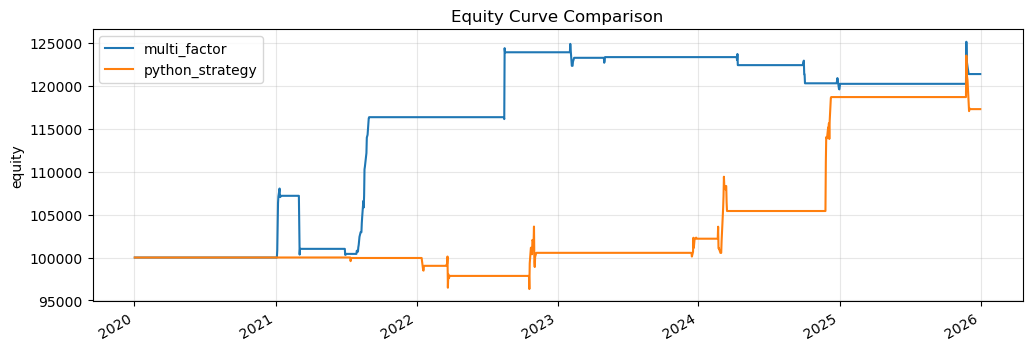

In [24]:
def summarize_alpha_activity(name: str, target_position: pd.DataFrame) -> dict:

    action_counts = target_position['action_name'].value_counts()

    position_series = target_position['target_position'].astype(float)

    signal_series = target_position['signal_value'].astype(float)

    return {

        'path': name,

        'rows': int(len(target_position)),

        'nonzero_signal_bars': int((signal_series.abs() > 1e-12).sum()),

        'long_bars': int((position_series > 0).sum()),

        'flat_bars': int((position_series == 0).sum()),

        'short_bars': int((position_series < 0).sum()),

        'position_changes': int((position_series.diff().abs() > 1e-9).sum()),

        'trade_actions': int((target_position['action_name'] != 'HOLD').sum()),

        'entry_long': int(action_counts.get('ENTRY_LONG', 0)),

        'exit_long': int(action_counts.get('EXIT_LONG', 0)),

        'entry_short': int(action_counts.get('ENTRY_SHORT', 0)),

        'exit_short': int(action_counts.get('EXIT_SHORT', 0)),

    }



activity_comparison = pd.DataFrame(

    [

        summarize_alpha_activity('multi_factor', multi_factor_target_position),

        summarize_alpha_activity('python_strategy', python_target_position),

    ]

)

display(activity_comparison)



comparison = pd.DataFrame(

    [

        {

            'path': 'multi_factor',

            'bars': multi_factor_report['summary']['bars'],

            'start': str(multi_factor_report['summary']['start']),

            'end': str(multi_factor_report['summary']['end']),

            'final_equity': multi_factor_report['summary']['final_equity'],

            'total_return': multi_factor_report['metrics'].get('total_return'),

            'annual_return': multi_factor_report['metrics'].get('annual_return'),

            'sharpe': multi_factor_report['metrics'].get('sharpe'),

            'max_drawdown': multi_factor_report['metrics'].get('max_drawdown'),

            'turnover': multi_factor_report['metrics'].get('turnover'),

            'commission_paid': multi_factor_report['metrics'].get('commission_paid'),

        },

        {

            'path': 'python_strategy',

            'bars': python_strategy_report['summary']['bars'],

            'start': str(python_strategy_report['summary']['start']),

            'end': str(python_strategy_report['summary']['end']),

            'final_equity': python_strategy_report['summary']['final_equity'],

            'total_return': python_strategy_report['metrics'].get('total_return'),

            'annual_return': python_strategy_report['metrics'].get('annual_return'),

            'sharpe': python_strategy_report['metrics'].get('sharpe'),

            'max_drawdown': python_strategy_report['metrics'].get('max_drawdown'),

            'turnover': python_strategy_report['metrics'].get('turnover'),

            'commission_paid': python_strategy_report['metrics'].get('commission_paid'),

        },

    ]

)

display(comparison)



equity_curve_df = pd.concat(

    [

        multi_factor_report['returns']['equity_curve'].rename('multi_factor'),

        python_strategy_report['returns']['equity_curve'].rename('python_strategy'),

    ],

    axis=1,

)



try:

    import matplotlib.pyplot as plt



    ax = equity_curve_df.plot(figsize=(12, 4), title='Equity Curve Comparison')

    ax.set_ylabel('equity')

    ax.grid(True, alpha=0.3)

    plt.show()

except Exception as exc:

    print(f'Plot skipped: {exc}')

    display(equity_curve_df.tail(10))

In [11]:
artifact_paths = sorted(
    path.relative_to(DEMO_ROOT).as_posix()
    for path in DEMO_ROOT.rglob('*')
    if path.is_file()
)
display(pd.DataFrame({'generated_files': artifact_paths}))

,generated_files
0,__pycache__/python_strategy_path.cpython-311.pyc
1,cache/market_data/daily_market_summary/freq=1d...
2,cache/market_data/daily_market_summary/freq=1d...
3,configs/multi_factor_factor_lake.yaml
4,factor_lake/factors/demo_mom_5_v1/year=2020/da...
5,factor_lake/factors/demo_mom_5_v1/year=2021/da...
6,factor_lake/factors/demo_mom_5_v1/year=2022/da...
7,factor_lake/factors/demo_mom_5_v1/year=2023/da...
8,factor_lake/factors/demo_mom_5_v1/year=2024/da...
9,factor_lake/factors/demo_mom_5_v1/year=2025/da...
